# Online Retail Dataset KPI Analysis
# Author: Katsiaryna Chaikova
# Description: This notebook checks the quality of the Online Retail CSV dataset using four KPIs:
# Completeness, Latency, Accuracy, and Consistency.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from datetime import datetime

In [ ]:
file_name = "Online Retail.csv"

output_folder = "online_retail_results"
os.makedirs(output_folder, exist_ok=True)

df = pd.read_csv(file_name, encoding="ISO-8859-1", dtype={"InvoiceNo": str, "StockCode": str, "CustomerID": str})

print("Dataset loaded successfully")
print("Rows and columns:", df.shape)
df.head()

Dataset loaded successfully
Rows and columns: (541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850,United Kingdom


In [ ]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"], errors="coerce")
df["TotalPrice"] = df["Quantity"] * df["UnitPrice"]

df.to_csv(os.path.join(output_folder, "online_retail_prepared.csv"), index=False)

print("Prepared dataset saved")
df.head()

Prepared dataset saved


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34


## Descriptive Statistics

In [4]:
# Basic information about the dataset

print("Number of rows:", len(df))
print("Number of columns:", len(df.columns))
print("\nColumns:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

Number of rows: 541909
Number of columns: 9

Columns:
['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country', 'TotalPrice']

Data types:
InvoiceNo                 str
StockCode                 str
Description               str
Quantity                int64
InvoiceDate    datetime64[us]
UnitPrice             float64
CustomerID                str
Country                   str
TotalPrice            float64
dtype: object


In [5]:
# Descriptive statistics for numeric columns

descriptive_stats = df[["Quantity", "UnitPrice", "TotalPrice"]].describe()
descriptive_stats.to_csv(os.path.join(output_folder, "descriptive_statistics.csv"))

descriptive_stats

,Quantity,UnitPrice,TotalPrice
count,541909.000000,541909.000000,541909.000000
mean,9.552250,4.611114,17.987795
std,218.081158,96.759853,378.810824
min,-80995.000000,-11062.060000,-168469.600000
25%,1.000000,1.250000,3.400000
50%,3.000000,2.080000,9.750000
75%,10.000000,4.130000,17.400000
max,80995.000000,38970.000000,168469.600000


In [ ]:
summary_info = pd.DataFrame({
    "Metric": [
        "Number of transactions/rows",
        "Number of unique invoices",
        "Number of unique products",
        "Number of unique customers",
        "Number of countries",
        "Start date",
        "End date"
    ],
    "Value": [
        len(df),
        df["InvoiceNo"].nunique(),
        df["StockCode"].nunique(),
        df["CustomerID"].nunique(),
        df["Country"].nunique(),
        df["InvoiceDate"].min(),
        df["InvoiceDate"].max()
    ]
})

summary_info.to_csv(os.path.join(output_folder, "summary_information.csv"), index=False)
summary_info

,Metric,Value
0,Number of transactions/rows,541909
1,Number of unique invoices,25900
2,Number of unique products,4070
3,Number of unique customers,4372
4,Number of countries,38
5,Start date,2010-12-01 08:26:00
6,End date,2011-12-09 12:50:00


## Basic Visualizations

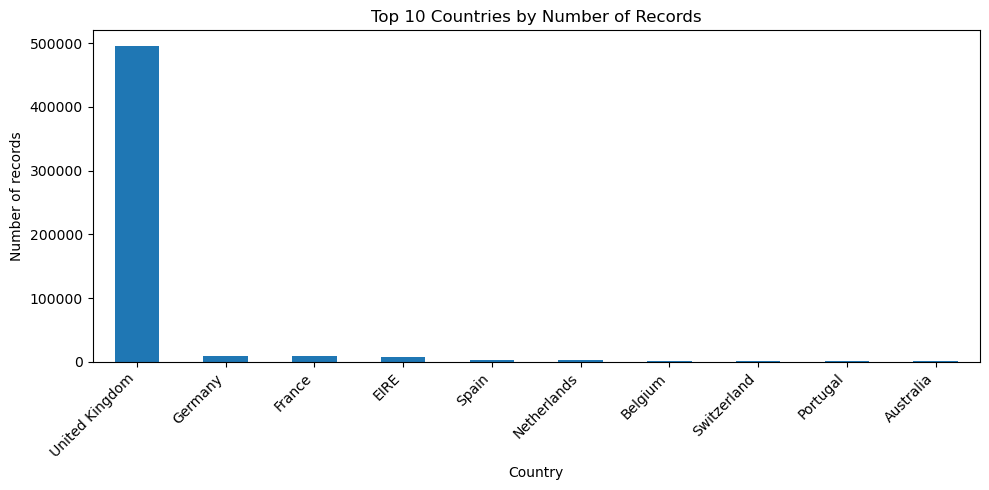

In [7]:
# Top 10 countries by number of rows

top_countries = df["Country"].value_counts().head(10)

plt.figure(figsize=(10, 5))
top_countries.plot(kind="bar")
plt.title("Top 10 Countries by Number of Records")
plt.xlabel("Country")
plt.ylabel("Number of records")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(os.path.join(output_folder, "top_countries.png"))
plt.show()

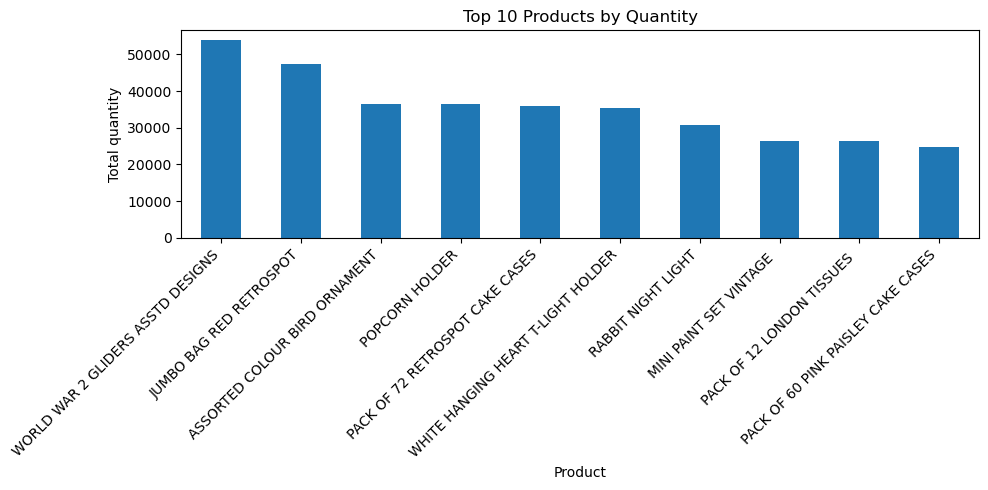

In [8]:
# Top 10 products by quantity sold

top_products = df.groupby("Description")["Quantity"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 5))
top_products.plot(kind="bar")
plt.title("Top 10 Products by Quantity")
plt.xlabel("Product")
plt.ylabel("Total quantity")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(os.path.join(output_folder, "top_products_by_quantity.png"))
plt.show()

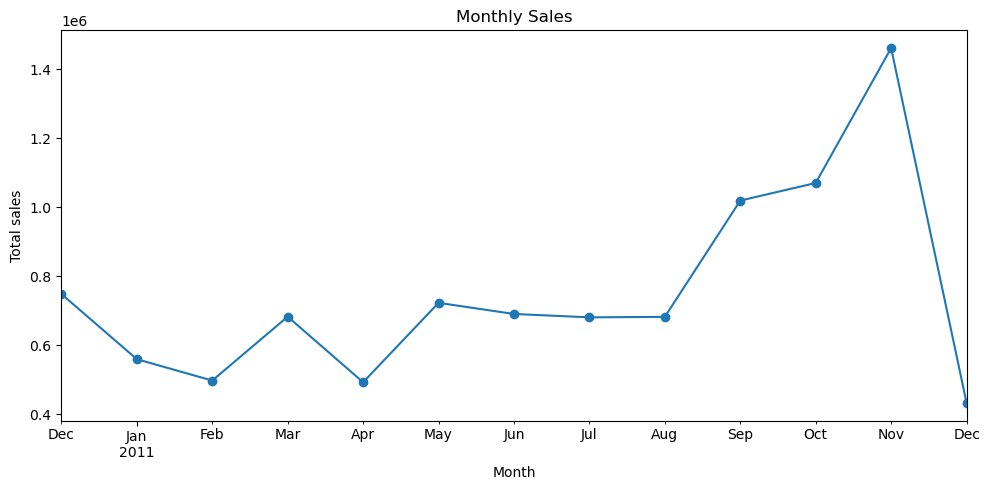

In [10]:
# Monthly sales

monthly_sales = df.set_index("InvoiceDate").resample("ME")["TotalPrice"].sum()

plt.figure(figsize=(10, 5))
monthly_sales.plot(kind="line", marker="o")
plt.title("Monthly Sales")
plt.xlabel("Month")
plt.ylabel("Total sales")
plt.tight_layout()
plt.savefig(os.path.join(output_folder, "monthly_sales.png"))
plt.show()

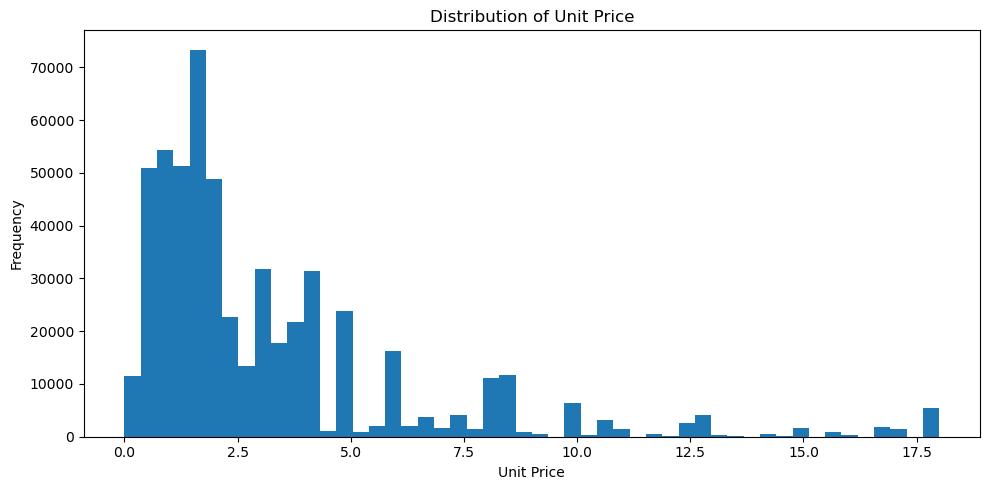

In [11]:
# Distribution of UnitPrice

plt.figure(figsize=(10, 5))
df[df["UnitPrice"] >= 0]["UnitPrice"].clip(upper=df["UnitPrice"].quantile(0.99)).plot(kind="hist", bins=50)
plt.title("Distribution of Unit Price")
plt.xlabel("Unit Price")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig(os.path.join(output_folder, "unit_price_distribution.png"))
plt.show()

## KPI 1 — Completeness

Completeness shows how much data is present and how much data is missing.

In [12]:
missing_values = df.isna().sum()
missing_percent = (missing_values / len(df)) * 100

completeness = pd.DataFrame({
    "Column": df.columns,
    "Missing Values": missing_values.values,
    "Missing Percent": missing_percent.values,
    "Completeness Percent": 100 - missing_percent.values
})

overall_completeness = 100 - (df.isna().sum().sum() / (df.shape[0] * df.shape[1]) * 100)

completeness.to_csv(os.path.join(output_folder, "kpi_completeness.csv"), index=False)

print("Overall completeness:", round(overall_completeness, 2), "%")
completeness

Overall completeness: 97.2 %


,Column,Missing Values,Missing Percent,Completeness Percent
0,InvoiceNo,0,0.000000,100.000000
1,StockCode,0,0.000000,100.000000
2,Description,1454,0.268311,99.731689
3,Quantity,0,0.000000,100.000000
4,InvoiceDate,0,0.000000,100.000000
5,UnitPrice,0,0.000000,100.000000
6,CustomerID,135080,24.926694,75.073306
7,Country,0,0.000000,100.000000
8,TotalPrice,0,0.000000,100.000000


## KPI 2 — Latency

Latency checks how fresh the dataset is.  
For this dataset, we compare the latest transaction date with today's date.

In [13]:
latest_date = df["InvoiceDate"].max()
earliest_date = df["InvoiceDate"].min()
today = pd.Timestamp.today()

latency_days = (today - latest_date).days

latency_result = pd.DataFrame({
    "Metric": ["Earliest invoice date", "Latest invoice date", "Current date", "Latency in days"],
    "Value": [earliest_date, latest_date, today, latency_days]
})

latency_result.to_csv(os.path.join(output_folder, "kpi_latency.csv"), index=False)

latency_result

,Metric,Value
0,Earliest invoice date,2010-12-01 08:26:00
1,Latest invoice date,2011-12-09 12:50:00
2,Current date,2026-04-26 16:08:10.356419
3,Latency in days,5252


## KPI 3 — Accuracy

Accuracy checks if the values look correct and realistic.  
For this dataset, I checked invalid dates, negative prices, zero prices, and unusual quantities.

In [ ]:
invalid_dates = df["InvoiceDate"].isna().sum()
negative_prices = (df["UnitPrice"] < 0).sum()
zero_prices = (df["UnitPrice"] == 0).sum()
negative_or_zero_quantity = (df["Quantity"] <= 0).sum()
missing_customer_id = df["CustomerID"].isna().sum()

quantity_outliers = (df["Quantity"].abs() > df["Quantity"].abs().quantile(0.99)).sum()
price_outliers = (df["UnitPrice"] > df["UnitPrice"].quantile(0.99)).sum()

accuracy = pd.DataFrame({
    "Check": [
        "Invalid dates",
        "Negative unit prices",
        "Zero unit prices",
        "Negative or zero quantity",
        "Missing CustomerID",
        "Quantity outliers above 99th percentile",
        "UnitPrice outliers above 99th percentile"
    ],
    "Number of records": [
        invalid_dates,
        negative_prices,
        zero_prices,
        negative_or_zero_quantity,
        missing_customer_id,
        quantity_outliers,
        price_outliers
    ],
    "Percent of dataset": [
        invalid_dates / len(df) * 100,
        negative_prices / len(df) * 100,
        zero_prices / len(df) * 100,
        negative_or_zero_quantity / len(df) * 100,
        missing_customer_id / len(df) * 100,
        quantity_outliers / len(df) * 100,
        price_outliers / len(df) * 100
    ]
})

accuracy.to_csv(os.path.join(output_folder, "kpi_accuracy.csv"), index=False)

accuracy

,Check,Number of records,Percent of dataset
0,Invalid dates,0,0.000000
1,Negative unit prices,2,0.000369
2,Zero unit prices,2515,0.464100
3,Negative or zero quantity,10624,1.960477
4,Missing CustomerID,135080,24.926694
5,Quantity outliers above 99th percentile,5406,0.997584
6,UnitPrice outliers above 99th percentile,4790,0.883912


In [ ]:
cancelled_invoices = df["InvoiceNo"].astype(str).str.startswith("C").sum()

print("Cancelled invoices/returns:", cancelled_invoices)
print("Negative or zero quantity rows:", negative_or_zero_quantity)

Cancelled invoices/returns: 9288
Negative or zero quantity rows: 10624


## KPI 4 — Consistency

Consistency checks whether the dataset follows the same format and logic across rows.

In [ ]:
duplicate_rows = df.duplicated().sum()

country_spaces = (df["Country"] != df["Country"].str.strip()).sum()
description_spaces = (df["Description"].dropna() != df["Description"].dropna().str.strip()).sum()

invoice_date_inconsistency = (df.groupby("InvoiceNo")["InvoiceDate"].nunique() > 1).sum()
invoice_customer_inconsistency = (df.groupby("InvoiceNo")["CustomerID"].nunique(dropna=True) > 1).sum()
invoice_country_inconsistency = (df.groupby("InvoiceNo")["Country"].nunique() > 1).sum()

consistency = pd.DataFrame({
    "Check": [
        "Duplicate rows",
        "Countries with extra spaces",
        "Descriptions with extra spaces",
        "Invoices with more than one invoice date",
        "Invoices with more than one customer ID",
        "Invoices with more than one country"
    ],
    "Number of records/issues": [
        duplicate_rows,
        country_spaces,
        description_spaces,
        invoice_date_inconsistency,
        invoice_customer_inconsistency,
        invoice_country_inconsistency
    ]
})

consistency.to_csv(os.path.join(output_folder, "kpi_consistency.csv"), index=False)

consistency

,Check,Number of records/issues
0,Duplicate rows,5268
1,Countries with extra spaces,0
2,Descriptions with extra spaces,113452
3,Invoices with more than one invoice date,43
4,Invoices with more than one customer ID,0
5,Invoices with more than one country,0


## Final KPI Summary

In [17]:
kpi_summary = pd.DataFrame({
    "KPI": ["Completeness", "Latency", "Accuracy", "Consistency"],
    "Main Result": [
        f"{overall_completeness:.2f}% overall completeness",
        f"{latency_days} days from latest invoice date to today",
        f"{negative_prices} negative prices, {zero_prices} zero prices, {negative_or_zero_quantity} negative/zero quantities",
        f"{duplicate_rows} duplicate rows, {invoice_customer_inconsistency} invoice-customer inconsistencies"
    ],
    "Interpretation": [
        "Shows how much of the dataset is filled and how much is missing.",
        "Shows whether the dataset is fresh or old.",
        "Shows suspicious or unrealistic values in the dataset.",
        "Shows duplicate rows and logical formatting problems."
    ]
})

kpi_summary.to_csv(os.path.join(output_folder, "KPI_RESULTS.csv"), index=False)

kpi_summary

,KPI,Main Result,Interpretation
0,Completeness,97.20% overall completeness,Shows how much of the dataset is filled and ho...
1,Latency,5252 days from latest invoice date to today,Shows whether the dataset is fresh or old.
2,Accuracy,"2 negative prices, 2515 zero prices, 10624 neg...",Shows suspicious or unrealistic values in the ...
3,Consistency,"5268 duplicate rows, 0 invoice-customer incons...",Shows duplicate rows and logical formatting pr...
